<a href="https://colab.research.google.com/github/LunaTic-Neon/2026-1-NLP/blob/main/26_1_0313_NLP_w2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.probability import FreqDist
from wordcloud import WordCloud

# NLTK 필요 데이터 다운로드
nltk.download('gutenberg')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

# 데이터 로드
emma_text = gutenberg.raw('austen-emma.txt')
print(f"데이터 로드 완료. 총 글자 수: {len(emma_text)}")

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...


데이터 로드 완료. 총 글자 수: 887071


[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# 1. 토큰화 (정규표현식 활용)
tokenizer = RegexpTokenizer(r'[a-zA-Z]+')
tokens = tokenizer.tokenize(emma_text.lower())

# NLTK 필요 데이터 다운로드 추가
nltk.download('averaged_perceptron_tagger_eng')

# 2. 품사 태깅 및 필터링
# 기준: 일반명사 단수(NN), 동사 원형(VB), 동사 3인칭 단수 현재(VBZ), 형용사(JJ)
pos_tags = nltk.pos_tag(tokens)
target_tags = ['NN', 'VB', 'VBZ', 'JJ']
filtered_words = [word for word, tag in pos_tags if tag in target_tags]

# 3. Stopword 제거
stop_words = set(stopwords.words('english'))

final_words = [word for word in filtered_words if word not in stop_words and len(word) > 1]
print(f"전처리 완료. 최종 단어 개수: {len(final_words)}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


전처리 완료. 최종 단어 개수: 42524


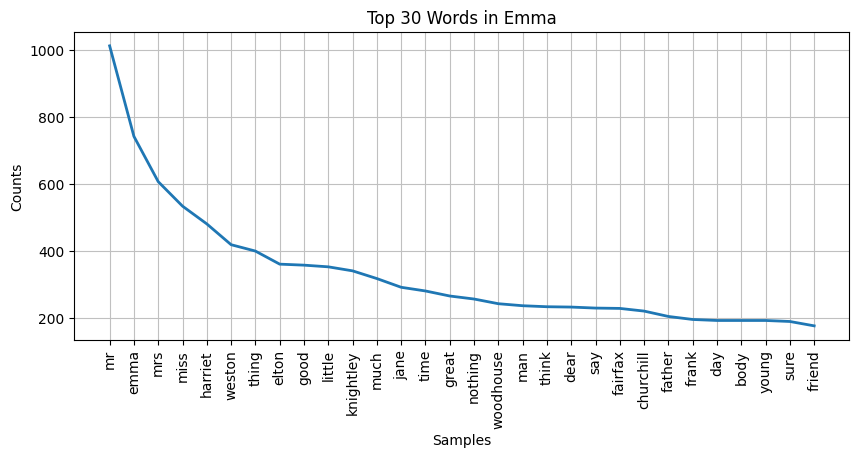

In [ ]:
# 빈도 분석 (상위 30단어 추출)
fd = FreqDist(final_words)
top_30_words = fd.most_common(30)

# 그래프 시각화
plt.figure(figsize=(10, 4))
fd.plot(30, title='Top 30 Words in Emma')
plt.show()

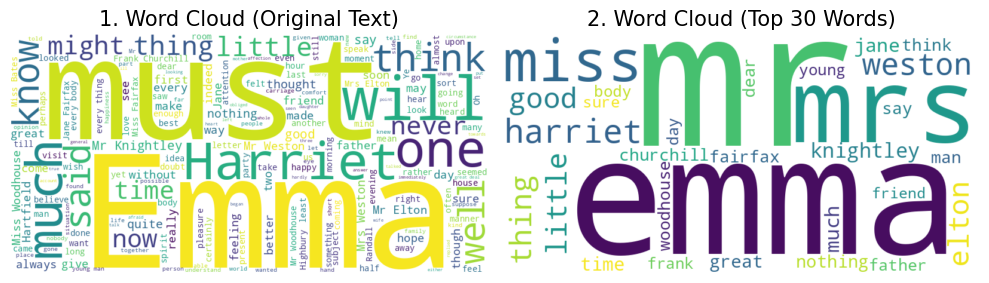

In [ ]:
# 1. 워드클라우드 생성
wc_original = WordCloud(width=800, height=400, background_color='white').generate(emma_text)

# 2. 빈도순 30단어 기준 워드클라우드 생성
top_30_dict = dict(top_30_words)
wc_top30 = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_30_dict)

# 두 워드클라우드 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(wc_original, interpolation='bilinear')
axes[0].set_title('1. Word Cloud (Original Text)', fontsize=15)
axes[0].axis('off')

axes[1].imshow(wc_top30, interpolation='bilinear')
axes[1].set_title('2. Word Cloud (Top 30 Words)', fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()